In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 设置字体为SimHei（黑体）
plt.rcParams['font.sans-serif'] = ['SimHei']
# 解决坐标轴负号显示问题
plt.rcParams['axes.unicode_minus'] = False

In [3]:
data = pd.read_csv('./data/train_cleaned.csv')

In [4]:
data.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,187,37,125591,2013-08-08,IN,500/1000,1000,1412.06,0,450947,...,3,?,57700,5770,5770,46160,Nissan,Maxima,2000,0
1,243,44,967713,1997-12-25,IL,250/500,500,809.11,0,600208,...,1,YES,51400,5140,10280,35980,Honda,Civic,1996,0
2,24,33,649082,1996-01-19,IL,500/1000,1000,1252.28,0,431277,...,1,NO,46800,4680,9360,32760,Jeep,Wrangler,2002,0
3,215,42,519312,2008-10-28,OH,500/1000,500,1848.81,0,435489,...,2,YES,68520,11420,5710,51390,Suburu,Legacy,2003,1
4,85,30,190588,2001-12-09,OH,100/300,1000,796.35,0,614166,...,1,YES,58960,5360,10720,42880,Ford,F150,2004,0


In [5]:
# ===== 1. 数据基本信息 =====
print("="*60)
print("原始数据信息")
print("="*60)
print(f"数据形状: {data.shape}")
print(f"\n数据类型:\n{data.dtypes}")
print(f"\n是否有缺失值:\n{data.isnull().sum().sum()}")
print(f"\n目标变量分布:\n{data['fraud_reported'].value_counts()}")

原始数据信息
数据形状: (700, 39)

数据类型:
months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                object
policy_state                    object
policy_csl                      object
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
insured_relationship            object
capital-gains                    int64
capital-loss                     int64
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_location               ob

In [6]:
# ===== 2. 时间特征提取 =====
print("\n" + "="*60)
print("提取时间特征")
print("="*60)

# 转换日期列为datetime类型
data['policy_bind_date'] = pd.to_datetime(data['policy_bind_date'])
data['incident_date'] = pd.to_datetime(data['incident_date'])

# 从policy_bind_date提取特征
data['bind_year'] = data['policy_bind_date'].dt.year
data['bind_month'] = data['policy_bind_date'].dt.month
data['bind_quarter'] = data['policy_bind_date'].dt.quarter
data['bind_day_of_week'] = data['policy_bind_date'].dt.dayofweek

# 从incident_date提取特征
data['incident_year'] = data['incident_date'].dt.year
data['incident_month'] = data['incident_date'].dt.month
data['incident_quarter'] = data['incident_date'].dt.quarter
data['incident_day_of_week'] = data['incident_date'].dt.dayofweek

# 计算policy_duration（从bind到incident的天数）
data['policy_duration_days'] = (data['incident_date'] - data['policy_bind_date']).dt.days

# 时间特征补充
data['is_weekend_incident'] = data['incident_day_of_week'].isin([5, 6]).astype(int)
data['is_night_incident'] = ((data['incident_hour_of_the_day'] >= 22) | 
                             (data['incident_hour_of_the_day'] < 6)).astype(int)

print(f"新增时间特征数量: {13}")
print(f"新增列: bind_year, bind_month, bind_quarter, bind_day_of_week,")
print(f"        incident_year, incident_month, incident_quarter, incident_day_of_week,")
print(f"        policy_duration_days, is_weekend_incident, is_night_incident")


提取时间特征
新增时间特征数量: 13
新增列: bind_year, bind_month, bind_quarter, bind_day_of_week,
        incident_year, incident_month, incident_quarter, incident_day_of_week,
        policy_duration_days, is_weekend_incident, is_night_incident


In [7]:
# ===== 3. 数值特征派生 =====
print("\n" + "="*60)
print("数值特征工程")
print("="*60)

# 保费相关特征
data['deductable_premium_ratio'] = data['policy_deductable'] / (data['policy_annual_premium'] + 1)
data['umbrella_limit_ratio'] = data['umbrella_limit'] / (data['policy_annual_premium'] + 1)

# 资本利得/损失特征
data['capital_net'] = data['capital-gains'] - data['capital-loss']
data['capital_total'] = data['capital-gains'] + data['capital-loss']
data['has_capital_gains'] = (data['capital-gains'] > 0).astype(int)
data['has_capital_loss'] = (data['capital-loss'] > 0).astype(int)

# 索赔相关特征
data['claim_ratio_injury'] = data['injury_claim'] / (data['total_claim_amount'] + 1)
data['claim_ratio_property'] = data['property_claim'] / (data['total_claim_amount'] + 1)
data['claim_ratio_vehicle'] = data['vehicle_claim'] / (data['total_claim_amount'] + 1)
data['claim_consistency'] = (data['injury_claim'] + data['property_claim'] + data['vehicle_claim']) / (data['total_claim_amount'] + 1)

# 年龄特征
data['age_group'] = pd.cut(data['age'], bins=[0, 25, 35, 45, 55, 65, 100], 
                           labels=['18-25', '25-35', '35-45', '45-55', '55-65', '65+'])
data['age_group'] = data['age_group'].astype(str)
data['is_senior'] = (data['age'] >= 65).astype(int)

# 车辆年龄特征
data['vehicle_age'] = 2024 - data['auto_year']
data['vehicle_age_sq'] = data['vehicle_age'] ** 2

# 事故特征
data['total_injuries_and_damage'] = data['bodily_injuries'] + data['number_of_vehicles_involved']
data['has_bodily_injuries'] = (data['bodily_injuries'] > 0).astype(int)
data['has_witnesses'] = (data['witnesses'] > 0).astype(int)
data['witness_ratio'] = data['witnesses'] / (data['number_of_vehicles_involved'] + 1)

# 文件完整性特征
data['report_completeness'] = (data['police_report_available'] == 'Yes').astype(int)

print(f"新增数值特征数量: {20}")
print("新增特征包括: 保费比率、资本利得特征、索赔比率、年龄分组、")
print("               车辆年龄、事故严重程度特征等")


数值特征工程
新增数值特征数量: 20
新增特征包括: 保费比率、资本利得特征、索赔比率、年龄分组、
               车辆年龄、事故严重程度特征等


In [8]:
# ===== 4. 分类特征编码 =====
print("\n" + "="*60)
print("分类特征编码")
print("="*60)

# 二元特征转换为0/1
binary_mapping = {'Yes': 1, 'No': 0, 'M': 1, 'F': 0}

for col in ['authorities_contacted', 'police_report_available', 'property_damage']:
    if col in data.columns:
        if col == 'property_damage':
            # property_damage 可能有 Yes/No 值
            data[col + '_binary'] = data[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)
        else:
            # 其他列使用标准的 Yes/No 映射
            data[col + '_binary'] = data[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# 保单CSL编码（Coverage Limit）
csl_mapping = {'100/300/100': 1, '250/500/250': 2, '500/1000/500': 3}
data['policy_csl_encoded'] = data['policy_csl'].map(csl_mapping).fillna(1).astype(int)

# 事件严重程度编码
severity_mapping = {'Minor Damage': 1, 'Major Damage': 2, 'Total Loss': 3}
data['incident_severity_encoded'] = data['incident_severity'].map(severity_mapping).fillna(1).astype(int)

# 州特征 - 识别高风险州（基于目标变量）
state_fraud_rate = data.groupby('policy_state')['fraud_reported'].mean().sort_values(ascending=False)
print(f"\n高风险州（欺诈率最高的5个）:")
print(state_fraud_rate.head())

high_risk_states = state_fraud_rate[state_fraud_rate > state_fraud_rate.median()].index.tolist()
data['is_high_risk_state'] = data['policy_state'].isin(high_risk_states).astype(int)

# 交通事故类型编码
data['collision_type_is_collision'] = (data['collision_type'] == 'Collision').astype(int)

# 职业特征 - 识别高风险职业
occupation_fraud_rate = data.groupby('insured_occupation')['fraud_reported'].mean().sort_values(ascending=False)
print(f"\n高风险职业（欺诈率最高的5个）:")
print(occupation_fraud_rate.head())

high_risk_occupations = occupation_fraud_rate[occupation_fraud_rate > occupation_fraud_rate.median()].index.tolist()
data['is_high_risk_occupation'] = data['insured_occupation'].isin(high_risk_occupations).astype(int)

# 教育程度编码
education_mapping = {'High School': 1, 'Associate': 2, 'Bachelor': 3, 'College': 2, 'Master': 4, 'Doctor': 5}
data['education_level_encoded'] = data['insured_education_level'].map(education_mapping).fillna(1).astype(int)

print(f"\n编码后的分类特征数量: {8}")
print("包括: CSL编码、严重程度、风险州标记、风险职业标记、教育程度编码等")


分类特征编码

高风险州（欺诈率最高的5个）:
policy_state
OH    0.281124
IN    0.266355
IL    0.227848
Name: fraud_reported, dtype: float64

高风险职业（欺诈率最高的5个）:
insured_occupation
exec-managerial     0.385965
sales               0.314815
transport-moving    0.300000
farming-fishing     0.285714
tech-support        0.280000
Name: fraud_reported, dtype: float64

编码后的分类特征数量: 8
包括: CSL编码、严重程度、风险州标记、风险职业标记、教育程度编码等



特征与目标变量的相关性

与目标变量相关性最高的15个特征:
vehicle_claim                  0.168768
total_claim_amount             0.159836
property_claim                 0.121190
is_high_risk_occupation        0.104520
incident_severity_encoded      0.091608
injury_claim                   0.080521
has_witnesses                  0.073317
witnesses                      0.072243
number_of_vehicles_involved    0.071055
total_injuries_and_damage      0.069407
deductable_premium_ratio       0.062715
claim_ratio_injury             0.059004
policy_deductable              0.051987
has_capital_gains              0.047479
capital_total                  0.041717
Name: fraud_reported, dtype: float64


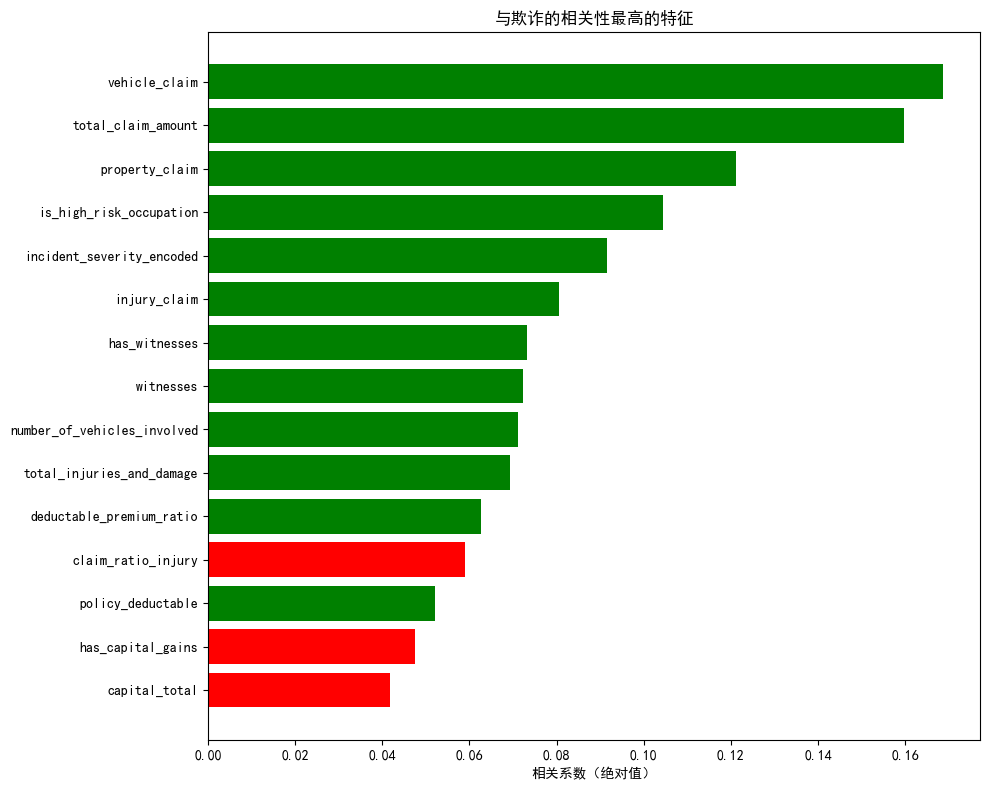


相关性低于0.01的特征数量: 4


In [9]:
# ===== 5. 特征相关性分析 =====
print("\n" + "="*60)
print("特征与目标变量的相关性")
print("="*60)

# 获取所有数值特征
numeric_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
# 移除目标变量
if 'fraud_reported' in numeric_features:
    numeric_features.remove('fraud_reported')

# 计算相关性
correlations = data[numeric_features + ['fraud_reported']].corr()['fraud_reported'].drop('fraud_reported')
correlations_sorted = correlations.abs().sort_values(ascending=False)

print("\n与目标变量相关性最高的15个特征:")
print(correlations_sorted.head(15))

# 可视化相关性
fig, ax = plt.subplots(figsize=(10, 8))
top_features = correlations_sorted.head(15)
colors = ['green' if correlations[feat] > 0 else 'red' for feat in top_features.index]
ax.barh(range(len(top_features)), top_features.values, color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index)
ax.set_xlabel('相关系数（绝对值）')
ax.set_title('与欺诈的相关性最高的特征')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# 低相关性特征应该被移除
low_correlation_threshold = 0.01
low_corr_features = correlations_sorted[correlations_sorted < low_correlation_threshold].index.tolist()
print(f"\n相关性低于{low_correlation_threshold}的特征数量: {len(low_corr_features)}")

In [10]:
# ===== 6. 多重共线性检测（VIF分析） =====
print("\n" + "="*60)
print("特征间多重共线性分析")
print("="*60)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# 选择数值特征计算VIF
numeric_data = data[numeric_features].copy()

# 数据清理：移除包含NaN或Inf的行
print(f"清理前数据形状: {numeric_data.shape}")

# 检查并报告缺失值
nan_count = numeric_data.isnull().sum()
if nan_count.sum() > 0:
    print(f"\n检测到缺失值:")
    print(nan_count[nan_count > 0])

# 检查并报告无穷大值
inf_count = np.isinf(numeric_data).sum()
if inf_count.sum() > 0:
    print(f"\n检测到无穷大值:")
    print(inf_count[inf_count > 0])

# 移除包含NaN或Inf的行
numeric_data_clean = numeric_data.dropna()
numeric_data_clean = numeric_data_clean[~np.isinf(numeric_data_clean).any(axis=1)]

print(f"清理后数据形状: {numeric_data_clean.shape}")
print(f"移除了 {numeric_data.shape[0] - numeric_data_clean.shape[0]} 行数据")

# 计算VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = numeric_data_clean.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_data_clean.values, i) for i in range(numeric_data_clean.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print("\nVIF值（>10表示存在多重共线性问题）:")
print(vif_data.head(15))

high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\n存在多重共线性问题的特征数量: {len(high_vif_features)}")
if high_vif_features:
    print("这些特征可能需要进一步处理或移除:")
    print(high_vif_features)


特征间多重共线性分析
清理前数据形状: (700, 48)
清理后数据形状: (700, 48)
移除了 0 行数据


f:\Python_workspace\practical_training\Fraud Detection in Insurance Claims\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
f:\Python_workspace\practical_training\Fraud Detection in Insurance Claims\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



VIF值（>10表示存在多重共线性问题）:
                        Feature          VIF
7                 capital-gains          inf
23                  capital_net          inf
24                capital_total          inf
17                    auto_year          inf
11              bodily_injuries          inf
10  number_of_vehicles_involved          inf
8                  capital-loss          inf
30            claim_consistency          inf
29          claim_ratio_vehicle          inf
32                  vehicle_age          inf
34    total_injuries_and_damage          inf
28         claim_ratio_property          inf
27           claim_ratio_injury          inf
13           total_claim_amount  4789.036573
16                vehicle_claim  2543.342193

存在多重共线性问题的特征数量: 22
这些特征可能需要进一步处理或移除:
['capital-gains', 'capital_net', 'capital_total', 'auto_year', 'bodily_injuries', 'number_of_vehicles_involved', 'capital-loss', 'claim_consistency', 'claim_ratio_vehicle', 'vehicle_age', 'total_injuries_and_damage', 'c

f:\Python_workspace\practical_training\Fraud Detection in Insurance Claims\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss



异常值检测和处理
age: 0 个异常值 (0.00%)
policy_annual_premium: 1 个异常值 (0.14%)
total_claim_amount: 0 个异常值 (0.00%)
injury_claim: 0 个异常值 (0.00%)
property_claim: 0 个异常值 (0.00%)
vehicle_claim: 0 个异常值 (0.00%)

总计包含异常值的样本: 1 个


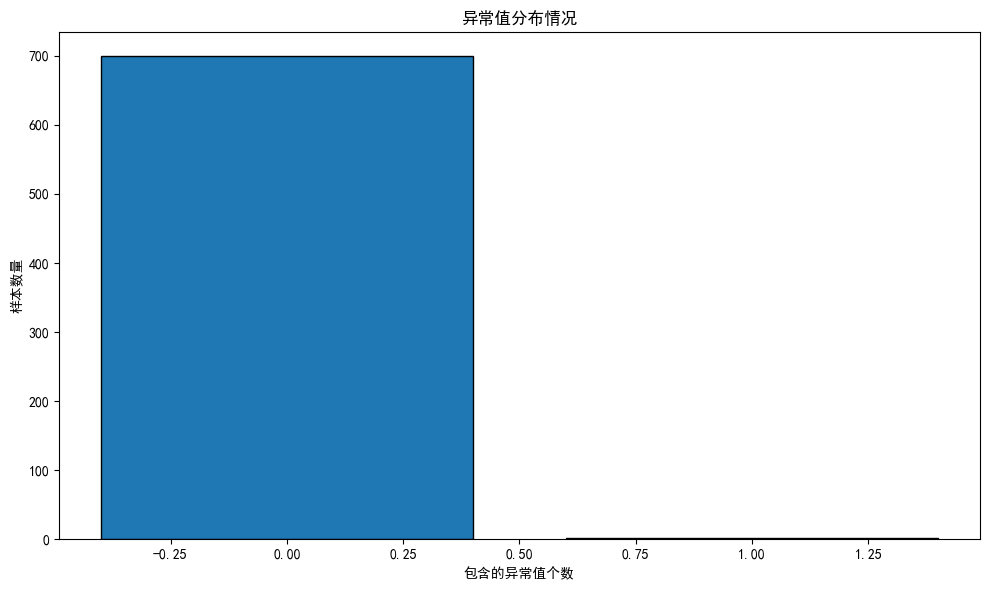

In [11]:
# ===== 7. 异常值检测（IQR方法） =====
print("\n" + "="*60)
print("异常值检测和处理")
print("="*60)

# 为关键数值特征创建异常值标记
outlier_features = ['age', 'policy_annual_premium', 'total_claim_amount', 
                    'injury_claim', 'property_claim', 'vehicle_claim']

data['outlier_count'] = 0

for feature in outlier_features:
    if feature in data.columns:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = ((data[feature] < lower_bound) | (data[feature] > upper_bound)).astype(int)
        data[f'{feature}_is_outlier'] = outliers
        data['outlier_count'] += outliers
        
        outlier_count = outliers.sum()
        print(f"{feature}: {outlier_count} 个异常值 ({outlier_count/len(data)*100:.2f}%)")

print(f"\n总计包含异常值的样本: {(data['outlier_count'] > 0).sum()} 个")

# 可视化异常值分布
fig, ax = plt.subplots(figsize=(10, 6))
outlier_dist = data['outlier_count'].value_counts().sort_index()
ax.bar(outlier_dist.index, outlier_dist.values, edgecolor='black')
ax.set_xlabel('包含的异常值个数')
ax.set_ylabel('样本数量')
ax.set_title('异常值分布情况')
plt.tight_layout()
plt.show()

In [12]:
# ===== 8. 特征缩放和标准化 =====
print("\n" + "="*60)
print("特征缩放准备")
print("="*60)

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 识别需要缩放的特征
scale_features = numerical_features = [col for col in numeric_features 
                                        if col not in [c for c in data.columns if 'is_' in c or 'encoded' in c]]

print(f"需要缩放的数值特征数量: {len(scale_features)}")
print(f"示例特征: {scale_features[:10]}")

# 创建缩放后的特征副本（不直接修改原数据）
scaler = StandardScaler()
data_scaled_features = data[scale_features].copy()
data_scaled_features_normalized = scaler.fit_transform(data_scaled_features)

print(f"\n缩放前的统计信息:")
print(f"  均值范围: [{data_scaled_features.mean().min():.2f}, {data_scaled_features.mean().max():.2f}]")
print(f"  方差范围: [{data_scaled_features.var().min():.2f}, {data_scaled_features.var().max():.2f}]")

print(f"\n缩放后的统计信息:")
print(f"  均值范围: [{data_scaled_features_normalized.mean(axis=0).min():.4f}, {data_scaled_features_normalized.mean(axis=0).max():.4f}]")
print(f"  方差范围: [{data_scaled_features_normalized.var(axis=0).min():.4f}, {data_scaled_features_normalized.var(axis=0).max():.4f}]")


特征缩放准备
需要缩放的数值特征数量: 39
示例特征: ['months_as_customer', 'age', 'policy_number', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day']

缩放前的统计信息:
  均值范围: [-26228.00, 549242.08]
  方差范围: [0.00, 66812149861.38]

缩放后的统计信息:
  均值范围: [-0.0000, 0.0000]
  方差范围: [0.0000, 1.0000]


In [13]:
# ===== 9. 最终特征选择和数据集准备 =====
print("\n" + "="*60)
print("最终特征集准备")
print("="*60)

# 移除原始日期列和低信息的列
columns_to_drop = ['policy_number', 'insured_zip', 'policy_bind_date', 'incident_date',
                   'policy_state', 'policy_csl', 'incident_state', 'incident_city', 
                   'incident_location', 'incident_type', 'collision_type', 
                   'incident_severity', 'authorities_contacted', 'property_damage',
                   'police_report_available', 'insured_occupation', 'insured_education_level',
                   'insured_hobbies', 'insured_relationship', 'insured_sex', 
                   'auto_make', 'auto_model']

data_final = data.drop(columns=columns_to_drop, errors='ignore')

print(f"原始特征数: {data.shape[1]}")
print(f"最终特征数: {data_final.shape[1]}")
print(f"移除的列数: {len(columns_to_drop)}")

# 显示最终数据集的信息
print(f"\n最终数据集形状: {data_final.shape}")
print(f"\n最终数据集列名:")
print(data_final.columns.tolist())

# 保存特征工程后的数据
data_final.to_csv('./data/train_features_engineered.csv', index=False)
print(f"\n已保存特征工程后的数据到: ./data/train_features_engineered.csv")


最终特征集准备
原始特征数: 85
最终特征数: 63
移除的列数: 22

最终数据集形状: (700, 63)

最终数据集列名:
['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year', 'fraud_reported', 'bind_year', 'bind_month', 'bind_quarter', 'bind_day_of_week', 'incident_year', 'incident_month', 'incident_quarter', 'incident_day_of_week', 'policy_duration_days', 'is_weekend_incident', 'is_night_incident', 'deductable_premium_ratio', 'umbrella_limit_ratio', 'capital_net', 'capital_total', 'has_capital_gains', 'has_capital_loss', 'claim_ratio_injury', 'claim_ratio_property', 'claim_ratio_vehicle', 'claim_consistency', 'age_group', 'is_senior', 'vehicle_age', 'vehicle_age_sq', 'total_injuries_and_damage', 'has_bodily_injuries', 'has_witnesses', 'witness_ratio', 'report_completeness', 'authorities_con

In [14]:
# ===== 10. 特征工程总结 =====
print("\n" + "="*60)
print("特征工程总结")
print("="*60)

summary = {
    '时间特征': {
        '描述': '从日期列提取的年、月、季度、周几等特征',
        '数量': 13,
        '特征名示例': ['bind_year', 'incident_month', 'is_weekend_incident', 'policy_duration_days']
    },
    '数值特征派生': {
        '描述': '各类比率、比值、交互特征等',
        '数量': 20,
        '特征名示例': ['deductable_premium_ratio', 'claim_ratio_injury', 'vehicle_age', 'has_bodily_injuries']
    },
    '分类特征编码': {
        '描述': '分类变量的编码和风险标记',
        '数量': 8,
        '特征名示例': ['policy_csl_encoded', 'is_high_risk_state', 'education_level_encoded']
    },
    '工程特征总数': {
        '描述': '新增的工程特征',
        '数量': 41,
        '特征名示例': []
    }
}

for category, info in summary.items():
    print(f"\n{category}:")
    print(f"  - 描述: {info['描述']}")
    print(f"  - 数量: {info['数量']}")
    if info['特征名示例']:
        print(f"  - 示例: {', '.join(info['特征名示例'][:3])}")

print("\n" + "="*60)
print("关键步骤总结:")
print("="*60)
print("✓ 1. 时间特征提取: 从日期列中提取了13个时间相关特征")
print("✓ 2. 数值特征派生: 创建了20个衍生的数值特征")
print("✓ 3. 分类特征编码: 对8种分类特征进行了编码和标记")
print("✓ 4. 相关性分析: 分析了特征与目标变量的相关性")
print("✓ 5. 多重共线性检测: 识别了存在共线性问题的特征")
print("✓ 6. 异常值检测: 标记了异常值样本")
print("✓ 7. 特征缩放: 准备了标准化处理方案")
print("✓ 8. 特征选择: 移除了低信息量的原始列")
print("\n数据已保存到: ./data/train_features_engineered.csv")


特征工程总结

时间特征:
  - 描述: 从日期列提取的年、月、季度、周几等特征
  - 数量: 13
  - 示例: bind_year, incident_month, is_weekend_incident

数值特征派生:
  - 描述: 各类比率、比值、交互特征等
  - 数量: 20
  - 示例: deductable_premium_ratio, claim_ratio_injury, vehicle_age

分类特征编码:
  - 描述: 分类变量的编码和风险标记
  - 数量: 8
  - 示例: policy_csl_encoded, is_high_risk_state, education_level_encoded

工程特征总数:
  - 描述: 新增的工程特征
  - 数量: 41

关键步骤总结:
✓ 1. 时间特征提取: 从日期列中提取了13个时间相关特征
✓ 2. 数值特征派生: 创建了20个衍生的数值特征
✓ 3. 分类特征编码: 对8种分类特征进行了编码和标记
✓ 4. 相关性分析: 分析了特征与目标变量的相关性
✓ 5. 多重共线性检测: 识别了存在共线性问题的特征
✓ 6. 异常值检测: 标记了异常值样本
✓ 7. 特征缩放: 准备了标准化处理方案
✓ 8. 特征选择: 移除了低信息量的原始列

数据已保存到: ./data/train_features_engineered.csv


In [16]:
# 对测试集进行相同的特征工程处理
test_data = pd.read_csv('./data/test.csv')
test_data['policy_bind_date'] = pd.to_datetime(test_data['policy_bind_date'])
test_data['incident_date'] = pd.to_datetime(test_data['incident_date']) 

In [17]:
print("="*60)
print("对测试集进行特征工程处理")
print("="*60)

# ===== 1. 时间特征提取 =====
print("\n提取时间特征...")

# 从policy_bind_date提取特征
test_data['bind_year'] = test_data['policy_bind_date'].dt.year
test_data['bind_month'] = test_data['policy_bind_date'].dt.month
test_data['bind_quarter'] = test_data['policy_bind_date'].dt.quarter
test_data['bind_day_of_week'] = test_data['policy_bind_date'].dt.dayofweek

# 从incident_date提取特征
test_data['incident_year'] = test_data['incident_date'].dt.year
test_data['incident_month'] = test_data['incident_date'].dt.month
test_data['incident_quarter'] = test_data['incident_date'].dt.quarter
test_data['incident_day_of_week'] = test_data['incident_date'].dt.dayofweek

# 计算policy_duration（从bind到incident的天数）
test_data['policy_duration_days'] = (test_data['incident_date'] - test_data['policy_bind_date']).dt.days

# 时间特征补充
test_data['is_weekend_incident'] = test_data['incident_day_of_week'].isin([5, 6]).astype(int)
test_data['is_night_incident'] = ((test_data['incident_hour_of_the_day'] >= 22) | 
                                   (test_data['incident_hour_of_the_day'] < 6)).astype(int)

# ===== 2. 数值特征派生 =====
print("派生数值特征...")

# 保费相关特征
test_data['deductable_premium_ratio'] = test_data['policy_deductable'] / (test_data['policy_annual_premium'] + 1)
test_data['umbrella_limit_ratio'] = test_data['umbrella_limit'] / (test_data['policy_annual_premium'] + 1)

# 资本利得/损失特征
test_data['capital_net'] = test_data['capital-gains'] - test_data['capital-loss']
test_data['capital_total'] = test_data['capital-gains'] + test_data['capital-loss']
test_data['has_capital_gains'] = (test_data['capital-gains'] > 0).astype(int)
test_data['has_capital_loss'] = (test_data['capital-loss'] > 0).astype(int)

# 索赔相关特征
test_data['claim_ratio_injury'] = test_data['injury_claim'] / (test_data['total_claim_amount'] + 1)
test_data['claim_ratio_property'] = test_data['property_claim'] / (test_data['total_claim_amount'] + 1)
test_data['claim_ratio_vehicle'] = test_data['vehicle_claim'] / (test_data['total_claim_amount'] + 1)
test_data['claim_consistency'] = (test_data['injury_claim'] + test_data['property_claim'] + test_data['vehicle_claim']) / (test_data['total_claim_amount'] + 1)

# 年龄特征
test_data['age_group'] = pd.cut(test_data['age'], bins=[0, 25, 35, 45, 55, 65, 100], 
                                 labels=['18-25', '25-35', '35-45', '45-55', '55-65', '65+'])
test_data['age_group'] = test_data['age_group'].astype(str)
test_data['is_senior'] = (test_data['age'] >= 65).astype(int)

# 车辆年龄特征
test_data['vehicle_age'] = 2024 - test_data['auto_year']
test_data['vehicle_age_sq'] = test_data['vehicle_age'] ** 2

# 事故特征
test_data['total_injuries_and_damage'] = test_data['bodily_injuries'] + test_data['number_of_vehicles_involved']
test_data['has_bodily_injuries'] = (test_data['bodily_injuries'] > 0).astype(int)
test_data['has_witnesses'] = (test_data['witnesses'] > 0).astype(int)
test_data['witness_ratio'] = test_data['witnesses'] / (test_data['number_of_vehicles_involved'] + 1)

# 文件完整性特征
test_data['report_completeness'] = (test_data['police_report_available'] == 'Yes').astype(int)

# ===== 3. 分类特征编码 =====
print("编码分类特征...")

# 二元特征转换为0/1
for col in ['authorities_contacted', 'police_report_available', 'property_damage']:
    if col in test_data.columns:
        if col == 'property_damage':
            test_data[col + '_binary'] = test_data[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)
        else:
            test_data[col + '_binary'] = test_data[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# 保单CSL编码
csl_mapping = {'100/300/100': 1, '250/500/250': 2, '500/1000/500': 3}
test_data['policy_csl_encoded'] = test_data['policy_csl'].map(csl_mapping).fillna(1).astype(int)

# 事件严重程度编码
severity_mapping = {'Minor Damage': 1, 'Major Damage': 2, 'Total Loss': 3}
test_data['incident_severity_encoded'] = test_data['incident_severity'].map(severity_mapping).fillna(1).astype(int)

# 州特征 - 使用训练数据中的高风险州列表
test_data['is_high_risk_state'] = test_data['policy_state'].isin(high_risk_states).astype(int)

# 交通事故类型编码
test_data['collision_type_is_collision'] = (test_data['collision_type'] == 'Collision').astype(int)

# 职业特征 - 使用训练数据中的高风险职业列表
test_data['is_high_risk_occupation'] = test_data['insured_occupation'].isin(high_risk_occupations).astype(int)

# 教育程度编码
education_mapping = {'High School': 1, 'Associate': 2, 'Bachelor': 3, 'College': 2, 'Master': 4, 'Doctor': 5}
test_data['education_level_encoded'] = test_data['insured_education_level'].map(education_mapping).fillna(1).astype(int)

# ===== 4. 异常值检测 =====
print("检测异常值...")

outlier_features = ['age', 'policy_annual_premium', 'total_claim_amount', 
                    'injury_claim', 'property_claim', 'vehicle_claim']

test_data['outlier_count'] = 0

for feature in outlier_features:
    if feature in test_data.columns:
        Q1 = test_data[feature].quantile(0.25)
        Q3 = test_data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = ((test_data[feature] < lower_bound) | (test_data[feature] > upper_bound)).astype(int)
        test_data[f'{feature}_is_outlier'] = outliers
        test_data['outlier_count'] += outliers

# ===== 5. 最终特征选择和数据集准备 =====
print("准备最终测试数据集...")

# 移除原始日期列和低信息的列
columns_to_drop = ['policy_number', 'insured_zip', 'policy_bind_date', 'incident_date',
                   'policy_state', 'policy_csl', 'incident_state', 'incident_city', 
                   'incident_location', 'incident_type', 'collision_type', 
                   'incident_severity', 'authorities_contacted', 'property_damage',
                   'police_report_available', 'insured_occupation', 'insured_education_level',
                   'insured_hobbies', 'insured_relationship', 'insured_sex', 
                   'auto_make', 'auto_model']

test_data_final = test_data.drop(columns=columns_to_drop, errors='ignore')

# 保存特征工程后的测试数据
test_data_final.to_csv('./data/test_features_engineered.csv', index=False)

print(f"\n✓ 测试集特征工程完成")
print(f"  - 原始列数: {test_data.shape[1]}")
print(f"  - 最终列数: {test_data_final.shape[1]}")
print(f"  - 样本数: {test_data_final.shape[0]}")
print(f"  - 已保存到: ./data/test_features_engineered.csv")


对测试集进行特征工程处理

提取时间特征...
派生数值特征...
编码分类特征...
检测异常值...
准备最终测试数据集...

✓ 测试集特征工程完成
  - 原始列数: 85
  - 最终列数: 63
  - 样本数: 300
  - 已保存到: ./data/test_features_engineered.csv
